In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. Load the dataset
df = pd.read_csv('AI.csv')

In [3]:
# 2. Data Cleaning
# Remove rows with missing values in key columns to ensure statistical integrity
df_clean = df.dropna(subset=['gender_bin', 'trait_risk']).copy()

In [4]:
df_clean.head()

,Number,risks_AI_avg,support_company,gender_bin,objective_threat,trait_risk,educ_short,percent_job_gain,age_group,education,country,manipulation_check2,weight
0,1,4.0,4.0,Men,NaN,certain,0,100%,45 to 64,HS or less,US,Pass,0.2703
2,3,3.0,4.0,Men,NaN,certain,0,70%,45 to 64,HS or less,US,Pass,0.6464
3,4,2.5,3.0,Men,0.466667,certain,0,100%,30 to 44,HS or less,US,Pass,2.7281
4,5,3.0,4.0,Men,NaN,certain,0,30%,65 or older,Some college,US,Fail,0.8643
5,6,6.5,4.0,Men,0.200000,certain,1,50%,30 to 44,University,US,Fail,0.9233


In [5]:
# 3. Basic Analysis: The Gender Gap
gender_gap = df_clean.groupby('gender_bin')['risks_AI_avg'].mean()
print("Average Risk Perception (0-10) by Gender:")
print(gender_gap)

Average Risk Perception (0-10) by Gender:
gender_bin
Men      4.426308
Women    4.832727
Name: risks_AI_avg, dtype: float64


In [6]:
# 4. Interaction Analysis: Replicating Paper Findings
# We group by both Risk Orientation ('certain' vs 'risky') and Gender
interaction = df_clean.groupby(['trait_risk', 'gender_bin'])['risks_AI_avg'].mean().unstack()
print("\nRisk Perception by Orientation and Gender:")
print(interaction)


Risk Perception by Orientation and Gender:
gender_bin       Men     Women
trait_risk                    
certain     4.554658  5.014079
risky       3.983607  3.884906


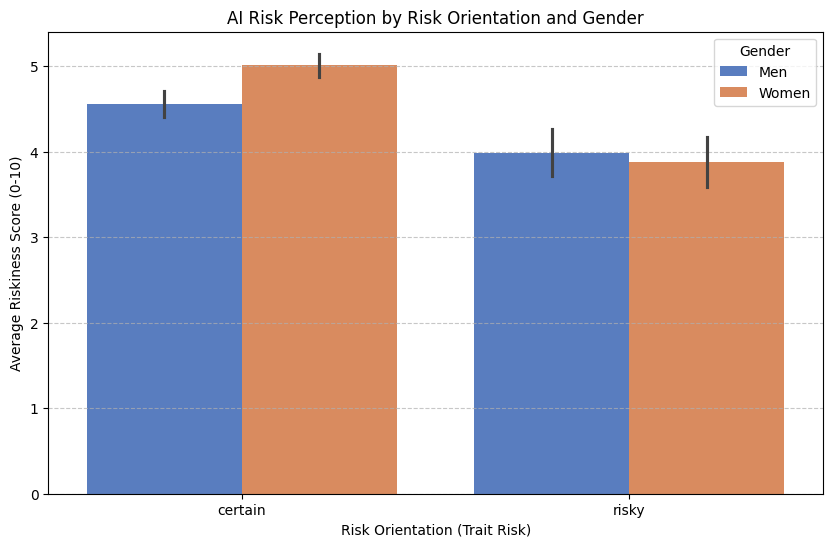

In [7]:
# 5. Visualization: Creating the Interaction Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df_clean, x='trait_risk', y='risks_AI_avg', hue='gender_bin', palette='muted')
plt.title('AI Risk Perception by Risk Orientation and Gender')
plt.ylabel('Average Riskiness Score (0-10)')
plt.xlabel('Risk Orientation (Trait Risk)')
plt.legend(title='Gender')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [8]:
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [9]:
# Filter for the specific subgroup: risk-averse (certain)
# and clean missing values
subgroup = df[(df['trait_risk'] == 'certain') & (df['gender_bin'].isin(['Men', 'Women']))].dropna(subset=['risks_AI_avg'])

In [10]:
# Split into Men and Women groups
women_risk = subgroup[subgroup['gender_bin'] == 'Women']['risks_AI_avg']
men_risk = subgroup[subgroup['gender_bin'] == 'Men']['risks_AI_avg']

# 1. Independent Samples T-Test (Welch's T-test - does not assume equal variance)
t_stat, p_val = stats.ttest_ind(women_risk, men_risk, equal_var=False)

# 2. Weighted OLS (to account for survey weights as the paper did)
# risks_AI_avg ~ gender_bin
# Note: statsmodels requires numeric or handled categoricals. 
# We'll map Women to 1 and Men to 0 for a simple regression coefficient interpretation.
subgroup['is_woman'] = (subgroup['gender_bin'] == 'Women').astype(int)
weighted_model = smf.wls('risks_AI_avg ~ is_woman', data=subgroup, weights=subgroup['weight']).fit()

In [11]:
print(f"--- Subgroup Analysis: 'Certain' Lottery Choice ---")
print(f"Sample size: Women={len(women_risk)}, Men={len(men_risk)}")
print(f"Unweighted Means: Women={women_risk.mean():.2f}, Men={men_risk.mean():.2f}")
print(f"\n1. Welch's T-Test (Unweighted):")
print(f"   T-statistic: {t_stat:.4f}")
print(f"   P-value: {p_val:.4g}")

print(f"\n2. Weighted OLS Regression Result:")
print(weighted_model.summary().tables[1])

--- Subgroup Analysis: 'Certain' Lottery Choice ---
Sample size: Women=1385, Men=1052
Unweighted Means: Women=5.01, Men=4.55

1. Welch's T-Test (Unweighted):
   T-statistic: 4.5044
   P-value: 6.997e-06

2. Weighted OLS Regression Result:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.4366      0.073     60.394      0.000       4.293       4.581
is_woman       0.5838      0.101      5.789      0.000       0.386       0.782
